# Module 01: Grids, Galaxies, and Ray-Tracing

## Learning to Autolens

---

**Purpose:** Introduce the core computational building blocks of PyAutoLens — the objects that
translate gravitational lensing theory into code. By the end of this module you will understand
how PyAutoLens represents grids, light profiles, mass profiles, galaxies, and the ray-tracing
operation that produces lensed images.

**Prerequisites:**
- Gravitational lensing fundamentals (lens equation, Einstein radius, convergence, shear)
- Basic Python (NumPy, Matplotlib)
- PyAutoLens installed (`pip install autolens`)

**Key references:**
- Congdon & Keeton (2018), *Principles of Gravitational Lensing*, Chapters 3–4 (hereafter **C&K**)
- Narayan & Bartelmann (1997), *Lectures on Gravitational Lensing*, Sections 2–3 (hereafter **N&B**)
- Nightingale, Dye & Massey (2018), *AutoLens: automated modeling of a strong lens's mass...* (hereafter **Nightingale+18**)

**Companion Mathematica script:** `../../Mathematica/01_lens_equation_and_profiles.wl`

---

## Table of Contents

1. [The Image Plane Grid](#1-the-image-plane-grid)
2. [Light Profiles: Describing Galaxy Brightness](#2-light-profiles)
3. [Mass Profiles: Describing Gravitational Potential](#3-mass-profiles)
4. [Galaxies: Composing Light and Mass](#4-galaxies)
5. [The Tracer: Ray-Tracing and the Lens Equation](#5-the-tracer)
6. [Critical Curves and Caustics](#6-critical-curves-and-caustics)
7. [Multi-Plane Lensing](#7-multi-plane-lensing)
8. [Exercises](#8-exercises)

## Setup

We import PyAutoLens and its plotting module. All PyAutoLens objects live under the `al` namespace,
and all plotting utilities under `aplt`.

In [26]:
# ============================================================
# IMPORTS
# ============================================================
# autolens: primary lens modeling package
# autolens.plot: visualization utilities (wraps matplotlib)
# numpy: numerical operations on grids and arrays
# matplotlib: custom plotting beyond autolens defaults
# ============================================================

import autolens as al
import autolens.plot as aplt

import numpy as np
import matplotlib.pyplot as plt

%matplotlib inline

print(f"PyAutoLens version: {al.__version__}")

PyAutoLens version: 2025.11.18.1


---

## 1. The Image Plane Grid <a id="1-the-image-plane-grid"></a>

### Theory: The Lens Equation on a Grid

The fundamental equation of gravitational lensing maps angular positions in the
**image plane** ($\boldsymbol{\theta}$) to the **source plane** ($\boldsymbol{\beta}$)
via the deflection angle $\boldsymbol{\alpha}$:

$$
\boldsymbol{\beta} = \boldsymbol{\theta} - \boldsymbol{\alpha}(\boldsymbol{\theta})
$$

(C&K eq. 4.1; N&B eq. 3)

To evaluate this computationally, we need a **discrete grid** of angular positions
in the image plane. Each grid point represents a sky coordinate (in arc-seconds from
the optical axis), and the deflection angle is computed at every point.

PyAutoLens uses `Grid2D` objects for this purpose. A `Grid2D` is a 2D array of
(y, x) coordinate pairs, stored in two formats:
- **`native`**: shape `(N_y, N_x, 2)` — the natural 2D layout
- **`slim`**: shape `(N_y * N_x, 2)` — flattened for vectorized computation

### Why (y, x) and not (x, y)?

PyAutoLens follows the NumPy/image convention where the first axis is the vertical
(y) axis and the second is horizontal (x). This matches how 2D arrays are indexed
in Python: `array[row, col]` = `array[y, x]`.

In [27]:
# ============================================================
# CREATE THE IMAGE-PLANE GRID
# ============================================================
# shape_native: (N_y, N_x) — number of pixels along each axis.
#   More pixels = finer angular resolution but more computation.
#   101x101 is a good starting point for exploration.
#
# pixel_scales: angular size of each pixel in arc-seconds.
#   0.1" is typical for HST-quality imaging.
#   The total field of view = shape * pixel_scales.
#   Here: 101 * 0.1" = 10.1" on a side.
# ============================================================

grid = al.Grid2D.uniform(
    shape_native=(101, 101),   # 101 x 101 pixels
    pixel_scales=0.1,          # 0.1 arc-seconds per pixel
)

# The grid is centered at (0, 0) by default — the optical axis.
# Let's inspect its properties.
print(f"Native shape: {grid.shape_native}")     # (101, 101)
print(f"Slim shape:   {grid.shape_slim}")       # (10201,)
print(f"Pixel scale:  {grid.pixel_scales} arcsec/pixel")
print(f"\nGrid center (native): {grid.native[50, 50]}")
print(f"Grid corner (native): {grid.native[0, 0]}")
print(f"\nField of view: {101 * 0.1:.1f}\" x {101 * 0.1:.1f}\"")

Native shape: (101, 101)
Slim shape:   10201
Pixel scale:  (0.1, 0.1) arcsec/pixel

Grid center (native): [-0.  0.]
Grid corner (native): [ 5. -5.]

Field of view: 10.1" x 10.1"


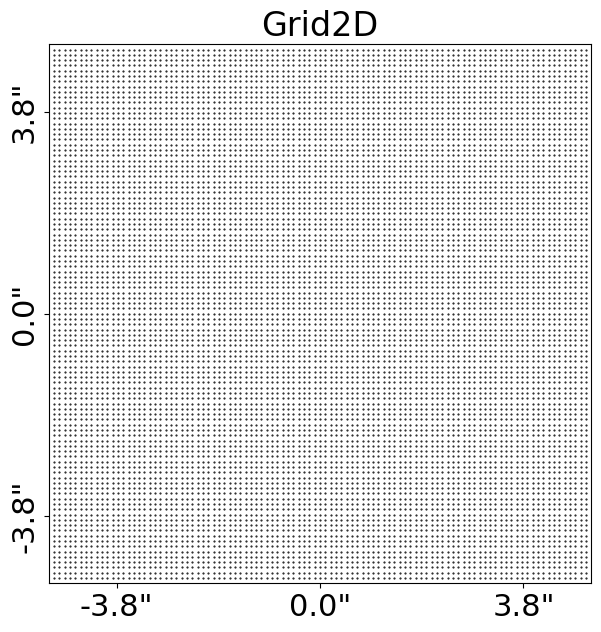

In [28]:
# ============================================================
# VISUALIZE THE GRID
# ============================================================
# Every dot is one grid point — one sky position where we will
# compute deflections, convergence, and lensed images.
# ============================================================

grid_plotter = aplt.Grid2DPlotter(grid=grid)
grid_plotter.figure_2d()

### Key takeaway

The `Grid2D` is the computational backbone: every lensing quantity (deflection angles,
convergence, shear, images) is evaluated on this grid. Choosing the grid resolution and
field of view is the first modeling decision you make.

---

## 2. Light Profiles: Describing Galaxy Brightness <a id="2-light-profiles"></a>

### Theory: The Sérsic Profile

The surface brightness of a galaxy is commonly described by the **Sérsic profile**
(Sérsic 1963):

$$
I(R) = I_e \exp\left\{ -b_n \left[ \left(\frac{R}{R_e}\right)^{1/n} - 1 \right] \right\}
$$

where:
- $R_e$ = effective (half-light) radius
- $n$ = Sérsic index: controls the profile shape
  - $n = 1$: exponential disk
  - $n = 4$: de Vaucouleurs profile (elliptical galaxies)
- $b_n \approx 2n - 1/3$ ensures $R_e$ encloses half the total light
- $I_e$ = intensity at $R_e$

(C&K Sec. 2.1; Meneghetti Sec. 2.3)

### Ellipticity Parameterization

Real galaxies are not circular. PyAutoLens parameterizes ellipticity using
**elliptical components** $(\epsilon_1, \epsilon_2)$ rather than axis ratio $q$
and position angle $\phi$. The conversion is:

$$
\epsilon_1 = \frac{1-q}{1+q} \sin(2\phi), \qquad
\epsilon_2 = \frac{1-q}{1+q} \cos(2\phi)
$$

This avoids discontinuities at $\phi = 0$ and $\phi = \pi$ and is standard in
weak lensing (cf. N&B Sec. 4.1). The total ellipticity magnitude is
$|\epsilon| = (1-q)/(1+q)$.

In [29]:
# ============================================================
# SÉRSIC LIGHT PROFILE
# ============================================================
# We create an elliptical Sérsic profile to represent a
# typical lens galaxy (e.g., an elliptical with n ~ 4).
#
# Parameters:
#   centre:           (y, x) position in arc-seconds
#   ell_comps:        (epsilon_1, epsilon_2) ellipticity components
#   intensity:        surface brightness normalization
#   effective_radius: half-light radius R_e in arc-seconds
#   sersic_index:     profile shape parameter n
# ============================================================

# An elliptical galaxy (de Vaucouleurs-like, n=4)
sersic_elliptical = al.lp.Sersic(
    centre=(0.0, 0.0),
    ell_comps=(0.1, 0.05),        # Mildly elliptical
    intensity=1.0,
    effective_radius=1.0,          # 1" half-light radius
    sersic_index=4.0,              # de Vaucouleurs profile
)

# A disk galaxy (exponential, n=1)
sersic_disk = al.lp.Sersic(
    centre=(0.0, 0.0),
    ell_comps=(0.3, 0.0),         # More elongated (disk-like)
    intensity=0.5,
    effective_radius=2.0,          # Larger extent
    sersic_index=1.0,              # Exponential profile
)

# Evaluate the brightness at every grid point.
# This returns an Array2D — the 2D image of the galaxy.
image_elliptical = sersic_elliptical.image_2d_from(grid=grid)
image_disk = sersic_disk.image_2d_from(grid=grid)

print(f"Elliptical image shape (native): {image_elliptical.native.shape}")
print(f"Peak brightness: {image_elliptical.native.max():.3f}")

Elliptical image shape (native): (101, 101)
Peak brightness: 81.040


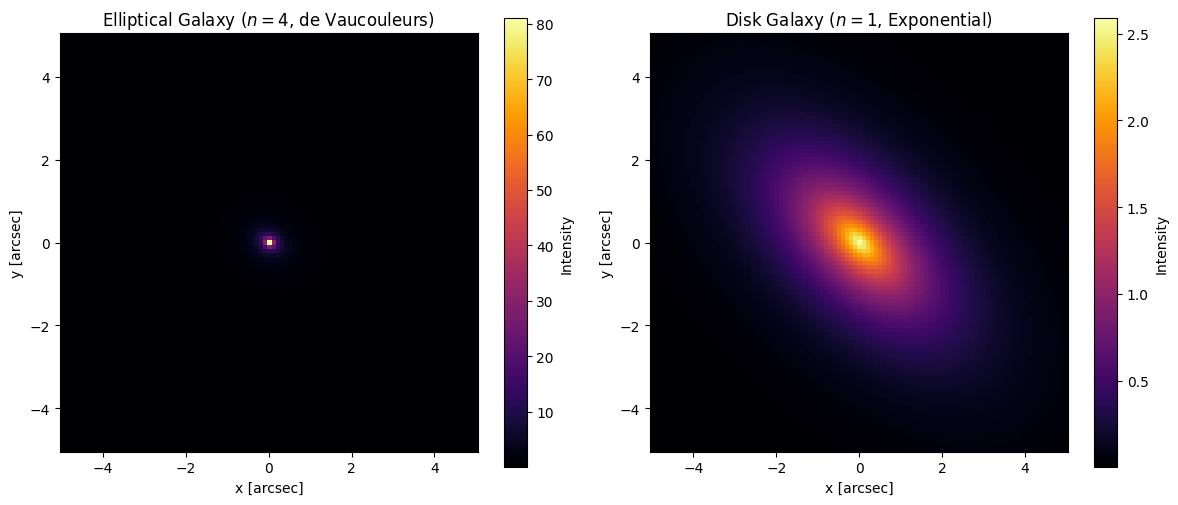

In [30]:
# ============================================================
# VISUALIZE: ELLIPTICAL vs. DISK
# ============================================================
# Compare how the Sérsic index changes the profile shape.
# n=4 is centrally concentrated (elliptical galaxy),
# n=1 is more extended (disk galaxy).
# ============================================================

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Elliptical (n=4)
im0 = axes[0].imshow(
    image_elliptical.native,
    extent=[-5.05, 5.05, -5.05, 5.05],  # Field of view in arcsec
    origin="lower",
    cmap="inferno",
)
axes[0].set_title(r"Elliptical Galaxy ($n = 4$, de Vaucouleurs)", fontsize=12)
axes[0].set_xlabel('x [arcsec]')
axes[0].set_ylabel('y [arcsec]')
plt.colorbar(im0, ax=axes[0], label="Intensity")

# Disk (n=1)
im1 = axes[1].imshow(
    image_disk.native,
    extent=[-5.05, 5.05, -5.05, 5.05],
    origin="lower",
    cmap="inferno",
)
axes[1].set_title(r"Disk Galaxy ($n = 1$, Exponential)", fontsize=12)
axes[1].set_xlabel('x [arcsec]')
axes[1].set_ylabel('y [arcsec]')
plt.colorbar(im1, ax=axes[1], label="Intensity")

plt.tight_layout()
plt.show()

In [ ]:
# ============================================================
# RADIAL PROFILE: BUILT-IN PLOTTING
# ============================================================
# PyAutoLens's LightProfilePlotter can produce 2D images of
# any light profile evaluated on the grid.
# ============================================================

# Use PyAutoLens built-in 2D plotting
light_plotter = aplt.LightProfilePlotter(
    light_profile=sersic_elliptical, grid=grid
)
light_plotter.figures_2d(image=True)

---

## 3. Mass Profiles: Describing Gravitational Potential <a id="3-mass-profiles"></a>

### Theory: From Mass to Deflection

The deflection angle for a thin gravitational lens is determined by the **convergence**
$\kappa(\boldsymbol{\theta})$, the dimensionless surface mass density:

$$
\kappa(\boldsymbol{\theta}) = \frac{\Sigma(\boldsymbol{\theta})}{\Sigma_{\rm cr}}
$$

where $\Sigma$ is the projected surface mass density and $\Sigma_{\rm cr}$ is the
**critical surface mass density** (C&K eq. 4.5; N&B eq. 10):

$$
\Sigma_{\rm cr} = \frac{c^2}{4\pi G} \frac{D_s}{D_d D_{ds}}
$$

The deflection angle is related to the convergence via the **lensing potential** $\psi$:

$$
\nabla^2 \psi = 2\kappa, \qquad \boldsymbol{\alpha} = \nabla \psi
$$

(C&K eq. 4.14–4.15; N&B eq. 8)

### Common Mass Models

| Model | Convergence $\kappa(\theta)$ | Key feature | Reference |
|-------|----------------------------|-------------|----------|
| **SIS** (Singular Isothermal Sphere) | $\kappa = \theta_E / (2\theta)$ | Flat rotation curves | C&K Sec. 4.3 |
| **SIE** (Singular Isothermal Ellipsoid) | Elliptical generalization of SIS | Galaxy-scale lenses | Kormann+ 1994 |
| **NFW** (Navarro-Frenk-White) | $\kappa(x) = f(x) / (x^2 - 1)$ | Dark matter halos | NFW 1996, C&K Sec. 4.5 |
| **Power Law** | $\kappa \propto \theta^{1-\gamma'}$ | Flexible slope | C&K Sec. 4.4 |

where $\theta_E$ is the **Einstein radius** — the characteristic angular scale of
strong lensing (C&K eq. 4.9):

$$
\theta_E = \sqrt{\frac{4GM}{c^2} \frac{D_{ds}}{D_d D_s}}
$$

In PyAutoLens, mass profiles live under `al.mp` and accept the same `centre` and
`ell_comps` parameterization as light profiles.

In [ ]:
# ============================================================
# SINGULAR ISOTHERMAL SPHERE (SIS)
# ============================================================
# The SIS is the simplest realistic lens model. Its deflection
# angle is constant: α = θ_E (independent of θ!).
# This produces exactly 2 images for any source inside θ_E.
#
# Physical motivation: an isothermal mass distribution has
# ρ ∝ r^{-2}, giving a flat rotation curve — exactly what we
# observe for galaxy-scale lenses.
# (cf. C&K Sec. 4.3, N&B Sec. 3.1)
# ============================================================

sis = al.mp.IsothermalSph(
    centre=(0.0, 0.0),
    einstein_radius=1.6,   # θ_E = 1.6" — typical for a massive elliptical at z~0.5
)

# Compute the key lensing quantities at every grid point.
deflections_sis = sis.deflections_yx_2d_from(grid=grid)  # α(θ)
convergence_sis = sis.convergence_2d_from(grid=grid)      # κ(θ)
potential_sis   = sis.potential_2d_from(grid=grid)         # ψ(θ)

print(f"Deflection at grid center: {deflections_sis.native[50, 50]}")
print(f"Deflection at (0, 3.0\"): α_y={deflections_sis.native[50, 80][0]:.4f}\", "
      f"α_x={deflections_sis.native[50, 80][1]:.4f}\"")
print(f"\nConvergence at center: κ = {convergence_sis.native[50, 50]:.4f}")
print(f"Convergence at 2\": κ = {convergence_sis.native[50, 70]:.4f}")

In [ ]:
# ============================================================
# VISUALIZE SIS LENSING QUANTITIES
# ============================================================
# Four key quantities that fully characterize the SIS lens:
#   - Convergence κ: projected mass density (∝ 1/θ for SIS)
#   - Deflection α_y, α_x: the lens equation displacement
#   - Gravitational potential ψ: satisfies ∇²ψ = 2κ
# ============================================================

mass_plotter = aplt.MassProfilePlotter(mass_profile=sis, grid=grid)
mass_plotter.figures_2d(
    convergence=True,
    deflections_y=True,
    deflections_x=True,
    potential=True,
)

In [ ]:
# ============================================================
# SINGULAR ISOTHERMAL ELLIPSOID (SIE)
# ============================================================
# The SIE is the workhorse of galaxy-scale lens modeling.
# It generalizes the SIS to elliptical isodensity contours,
# which is critical because real lens galaxies are elliptical.
#
# The SIE can produce 2 or 4 images depending on the source
# position relative to the caustics.
# (cf. Kormann, Schneider & Bartelmann 1994; C&K Sec. 4.6)
# ============================================================

sie = al.mp.Isothermal(
    centre=(0.0, 0.0),
    ell_comps=(0.1, 0.05),         # Elliptical mass distribution
    einstein_radius=1.6,
)

# Compare convergence maps: SIS (circular) vs SIE (elliptical)
convergence_sie = sie.convergence_2d_from(grid=grid)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

im0 = axes[0].imshow(
    np.log10(convergence_sis.native + 1e-6),
    extent=[-5.05, 5.05, -5.05, 5.05],
    origin="lower", cmap="magma",
)
axes[0].set_title(r"SIS: $\kappa(\theta) = \theta_E / 2\theta$", fontsize=12)
axes[0].set_xlabel('x [arcsec]')
axes[0].set_ylabel('y [arcsec]')
plt.colorbar(im0, ax=axes[0], label=r"$\log_{10}\kappa$")

im1 = axes[1].imshow(
    np.log10(convergence_sie.native + 1e-6),
    extent=[-5.05, 5.05, -5.05, 5.05],
    origin="lower", cmap="magma",
)
axes[1].set_title(r"SIE: Elliptical isodensity contours", fontsize=12)
axes[1].set_xlabel('x [arcsec]')
axes[1].set_ylabel('y [arcsec]')
plt.colorbar(im1, ax=axes[1], label=r"$\log_{10}\kappa$")

plt.tight_layout()
plt.show()

In [ ]:
# ============================================================
# EXTERNAL SHEAR
# ============================================================
# Real lenses sit in environments — nearby galaxies, groups,
# large-scale structure — that contribute a tidal gravitational
# field. This is modeled as "external shear" with two components
# (γ₁, γ₂) that add to the shear from the main lens.
#
# External shear is almost always included in lens models
# because neglecting it biases the mass model.
# (cf. C&K Sec. 4.7; N&B Sec. 3.3)
# ============================================================

shear = al.mp.ExternalShear(
    gamma_1=0.05,    # Shear component along x-axis
    gamma_2=0.02,    # Shear component at 45°
)

# Shear produces a uniform deflection pattern (no convergence).
deflections_shear = shear.deflections_yx_2d_from(grid=grid)
convergence_shear = shear.convergence_2d_from(grid=grid)

print(f"Shear convergence at center: {convergence_shear.native[50, 50]:.6f}")
print("(External shear contributes no convergence — it's a tidal field.)")

In [ ]:
# ============================================================
# NFW PROFILE (Dark Matter Halo)
# ============================================================
# The Navarro-Frenk-White (1996) profile describes the density
# of dark matter halos from cosmological N-body simulations:
#
#   ρ(r) = ρ_s / [(r/r_s)(1 + r/r_s)²]
#
# where r_s is the scale radius and ρ_s is a characteristic
# density. The convergence has a known analytic form.
# (cf. C&K Sec. 4.5; Bartelmann 1996)
# ============================================================

nfw = al.mp.NFWSph(
    centre=(0.0, 0.0),
    kappa_s=0.08,          # Characteristic convergence
    scale_radius=30.0,     # r_s in arc-seconds (large — galaxy group scale)
)

convergence_nfw = nfw.convergence_2d_from(grid=grid)

mass_plotter_nfw = aplt.MassProfilePlotter(mass_profile=nfw, grid=grid)
mass_plotter_nfw.figures_2d(convergence=True)

---

## 4. Galaxies: Composing Light and Mass <a id="4-galaxies"></a>

### Theory: A Galaxy is Light + Mass at a Redshift

In PyAutoLens, a `Galaxy` object combines:
1. A **redshift** — determines the cosmological distance and hence the lensing geometry
2. One or more **light profiles** — the observable surface brightness
3. One or more **mass profiles** — the gravitational potential

The key physical insight: **a galaxy's light and mass need not have the same profile**.
The visible light traces the stellar component, but the total mass includes dark matter
which has a different spatial distribution (typically more extended).

This is why lens modeling is so powerful for studying galaxy structure — it directly
constrains the total mass, not just the luminous mass.

### Multiple Mass Components

When a Galaxy has multiple mass profiles (e.g., SIE + external shear), PyAutoLens
**sums their deflection angles**. This follows from the superposition principle for
the lensing potential in the weak-field limit (cf. Learning to Lens Module 1e):

$$
\boldsymbol{\alpha}_{\rm total} = \sum_i \boldsymbol{\alpha}_i
$$

In [ ]:
# ============================================================
# LENS GALAXY: LIGHT + MASS + SHEAR
# ============================================================
# A typical galaxy-scale lens: elliptical galaxy at z=0.5 with
# Sérsic light (n=4), SIE mass, and external shear.
#
# The keyword names ('bulge', 'mass', 'shear') are arbitrary
# labels — PyAutoLens identifies profiles by type (light vs.
# mass) and sums them accordingly.
# ============================================================

lens_galaxy = al.Galaxy(
    redshift=0.5,
    bulge=al.lp.Sersic(
        centre=(0.0, 0.0),
        ell_comps=(0.1, 0.05),
        intensity=1.0,
        effective_radius=1.0,
        sersic_index=4.0,
    ),
    mass=al.mp.Isothermal(
        centre=(0.0, 0.0),
        ell_comps=(0.1, 0.05),       # Mass ellipticity ~ light ellipticity
        einstein_radius=1.6,
    ),
    shear=al.mp.ExternalShear(
        gamma_1=0.05,
        gamma_2=0.02,
    ),
)

print(f"Lens redshift: z_d = {lens_galaxy.redshift}")

# List all profiles attached to this galaxy
# profile_dict returns all profiles keyed by their label
for name, profile in lens_galaxy.profile_dict.items():
    profile_type = "light" if isinstance(profile, al.LightProfile) else "mass"
    print(f"  {name}: {profile.__class__.__name__} ({profile_type})")

In [ ]:
# ============================================================
# SOURCE GALAXY: LIGHT ONLY (no mass)
# ============================================================
# The background source is typically a star-forming galaxy
# at z ~ 1–3. It has light but its mass is irrelevant for
# the lensing (it's behind the lens plane).
#
# We offset it slightly from the optical axis — this breaks
# the symmetry and produces distinct multiple images rather
# than a perfect Einstein ring.
# ============================================================

source_galaxy = al.Galaxy(
    redshift=1.0,
    light=al.lp.Sersic(
        centre=(0.1, 0.05),          # Slightly offset from lens center
        ell_comps=(0.15, 0.1),       # Mildly elliptical
        intensity=0.5,
        effective_radius=0.5,         # Compact (0.5")
        sersic_index=1.0,            # Disk-like (star-forming)
    ),
)

In [ ]:
# ============================================================
# GALAXY-LEVEL LENSING QUANTITIES
# ============================================================
# The Galaxy object automatically sums all mass components.
# Here the total deflection = SIE deflection + shear deflection.
# ============================================================

# Image of the lens galaxy's light (unlensed — it's the foreground)
lens_image = lens_galaxy.image_2d_from(grid=grid)

# Total deflection from all mass components
total_deflections = lens_galaxy.deflections_yx_2d_from(grid=grid)

# Total convergence
total_convergence = lens_galaxy.convergence_2d_from(grid=grid)

galaxy_plotter = aplt.GalaxyPlotter(galaxy=lens_galaxy, grid=grid)
galaxy_plotter.figures_2d(image=True, convergence=True)

---

## 5. The Tracer: Ray-Tracing and the Lens Equation <a id="5-the-tracer"></a>

### Theory: From Image Plane to Source Plane

The **Tracer** is the central object in PyAutoLens. It takes a list of galaxies
(each with a redshift), sorts them into **planes** by redshift, and performs the
ray-tracing calculation:

1. Start with the image-plane grid $\boldsymbol{\theta}$
2. Compute the total deflection $\boldsymbol{\alpha}(\boldsymbol{\theta})$ from all mass in the lens plane
3. Apply the lens equation: $\boldsymbol{\beta} = \boldsymbol{\theta} - \boldsymbol{\alpha}(\boldsymbol{\theta})$
4. Evaluate the source brightness $I_s(\boldsymbol{\beta})$ at the deflected positions
5. The observed (lensed) image is $I_{\rm obs}(\boldsymbol{\theta}) = I_s(\boldsymbol{\beta}(\boldsymbol{\theta}))$

This is the computational implementation of the ray-tracing formalism
(C&K Ch. 4; Nightingale+18 Sec. 2).

### What makes this powerful

The Tracer handles:
- **Multi-plane lensing**: galaxies at multiple redshifts with sequential deflection
- **Cosmological distance computation**: uses the redshifts + a cosmology to compute $D_d$, $D_s$, $D_{ds}$
- **Automatic lens light inclusion**: the foreground galaxy's light is added to the lensed source image

In [ ]:
# ============================================================
# CREATE THE TRACER
# ============================================================
# The Tracer takes our lens and source galaxies and sets up
# the ray-tracing. It automatically:
#   1. Sorts galaxies by redshift into planes
#   2. Computes angular diameter distances
#   3. Performs the lens equation β = θ - α(θ)
# ============================================================

tracer = al.Tracer(
    galaxies=[lens_galaxy, source_galaxy],
    cosmology=al.cosmo.Planck15(),
)

print(f"Number of planes: {len(tracer.planes)}")
print(f"Plane 0 (image plane) redshift: {tracer.planes[0].redshift}")
print(f"Plane 1 (source plane) redshift: {tracer.planes[1].redshift}")

In [ ]:
# ============================================================
# RAY-TRACE: IMAGE-PLANE → SOURCE-PLANE
# ============================================================
# traced_grid_2d_list_from returns a list of grids, one per
# plane. The second grid (index 1) is the source-plane grid
# β = θ - α(θ) — this is the lens equation in action.
# ============================================================

traced_grids = tracer.traced_grid_2d_list_from(grid=grid)

image_plane_grid = traced_grids[0]    # θ (unchanged — it's the image plane)
source_plane_grid = traced_grids[1]   # β = θ - α(θ)

print("Image-plane grid (first 3 points):")
print(image_plane_grid.slim[:3])
print("\nSource-plane grid (first 3 points):")
print(source_plane_grid.slim[:3])
print("\nNotice how the source-plane coordinates differ from the image-plane —")
print("that's the deflection from the SIE + shear mass distribution.")

In [ ]:
# ============================================================
# THE LENSED IMAGE
# ============================================================
# tracer.image_2d_from combines:
#   - Lens galaxy light (evaluated on the image-plane grid)
#   - Source galaxy light (evaluated on the SOURCE-plane grid,
#     but mapped back to image-plane pixels)
#
# The source appears distorted, magnified, and often multiply
# imaged — the hallmark of strong gravitational lensing.
# ============================================================

lensed_image = tracer.image_2d_from(grid=grid)

tracer_plotter = aplt.TracerPlotter(tracer=tracer, grid=grid)
tracer_plotter.figures_2d(image=True)

In [ ]:
# ============================================================
# DECOMPOSED VIEW: LENS LIGHT + LENSED SOURCE
# ============================================================
# It's instructive to see the two components separately:
#   - Plane 0 image: the lens galaxy's own light (unlensed)
#   - Plane 1 image: the source galaxy's light after lensing
# The observed image is the sum of both.
# ============================================================

tracer_plotter.figures_2d_of_planes(plane_index=0, plane_image=True)
tracer_plotter.figures_2d_of_planes(plane_index=1, plane_image=True)

In [ ]:
# ============================================================
# THE SUBPLOT: COMPREHENSIVE RAY-TRACING SUMMARY
# ============================================================
# This subplot shows all key quantities in one figure:
# image, source-plane, convergence, deflections, potential.
# ============================================================

tracer_plotter.subplot_tracer()

In [ ]:
# ============================================================
# MANUAL RAY-TRACING: THE LENS EQUATION STEP BY STEP
# ============================================================
# To demystify what the Tracer does internally, let's perform
# the lens equation manually:
#   β = θ - α(θ)
#
# Note: The Tracer applies adaptive over-sampling to light
# profiles for sub-pixel accuracy. To match it exactly, we use
# the Tracer's own traced grid (which carries over-sampling
# metadata) for the comparison.
# ============================================================

# Step 1: Get the traced grids from the Tracer
# traced_grids[0] = image-plane grid (θ)
# traced_grids[1] = source-plane grid (β = θ - α)
traced_grids = tracer.traced_grid_2d_list_from(grid=grid)

# Step 2: Verify the lens equation: β = θ - α(θ)
alpha = lens_galaxy.deflections_yx_2d_from(grid=grid)
beta_manual = grid - alpha

# The coordinates should match exactly
import numpy as np
grid_diff = np.max(np.abs(np.array(traced_grids[1].slim) - np.array(beta_manual.slim)))
print(f"Grid coordinate difference (traced vs manual β): {grid_diff:.2e}")
print("(Should be ~0 — the Tracer computes β = θ - α exactly.)")

# Step 3: Evaluate source brightness on the traced source-plane grid
# Using traced_grids[1] ensures we get the same over-sampling as the Tracer.
source_image_check = source_galaxy.image_2d_from(grid=traced_grids[1])
tracer_source_image = tracer.image_2d_from(grid=grid)

# For a lens with light, subtract the lens light to isolate the source
lens_light = lens_galaxy.image_2d_from(grid=grid)
source_from_tracer = tracer_source_image - lens_light

print(f"\nSource image difference: {np.max(np.abs(source_image_check.native - source_from_tracer.native)):.2e}")
print("(The lens equation β = θ - α(θ) is confirmed!)")

### Understanding the Lensed Image

What you see in the image above is the combined light of the foreground lens galaxy
and the background source galaxy, where the source light has been **ray-traced** through
the lens's gravitational potential. The source appears as arcs or multiple images
surrounding the lens — this is the observational signature of strong lensing.

The key points:
1. **Magnification**: the source appears brighter than it would without lensing
2. **Distortion**: the source is stretched tangentially (forming arcs)
3. **Multiple imaging**: the same source can appear in 2 or 4 locations

All of this follows from the lens equation $\boldsymbol{\beta} = \boldsymbol{\theta} - \boldsymbol{\alpha}(\boldsymbol{\theta})$
being a non-linear mapping — different image-plane positions $\boldsymbol{\theta}$
can map to the same source-plane position $\boldsymbol{\beta}$.

---

## 6. Critical Curves and Caustics <a id="6-critical-curves-and-caustics"></a>

### Theory: Where Magnification Diverges

**Critical curves** are closed curves in the image plane where the magnification
formally diverges ($\det \mathbf{A} = 0$, where $\mathbf{A}$ is the Jacobian of the
lens mapping). Their image in the source plane is called the **caustic**.

The Jacobian matrix (the "magnification matrix") is (C&K eq. 5.7; N&B eq. 17):

$$
\mathbf{A} = \frac{\partial \boldsymbol{\beta}}{\partial \boldsymbol{\theta}} =
\begin{pmatrix}
1 - \kappa - \gamma_1 & -\gamma_2 \\
-\gamma_2 & 1 - \kappa + \gamma_1
\end{pmatrix}
$$

The magnification is $\mu = 1 / \det \mathbf{A} = 1 / [(1-\kappa)^2 - \gamma^2]$.

There are two types:
- **Tangential critical curve**: $1 - \kappa - \gamma = 0$ (images stretched tangentially → arcs)
- **Radial critical curve**: $1 - \kappa + \gamma = 0$ (images stretched radially)

When a source crosses a caustic, two new images appear or disappear as a pair.
This is the **catastrophe theory** classification of image configurations
(cf. C&K Ch. 5; Petters, Levine & Wambsganss 2001).

In [ ]:
# ============================================================
# CRITICAL CURVES AND CAUSTICS
# ============================================================
# PyAutoLens computes critical curves by finding where
# det(A) = 0 on the image-plane grid, then maps them to the
# source plane to get the caustics.
#
# For the SIE + shear, the tangential critical curve is
# approximately the Einstein ring (slightly deformed by
# ellipticity and shear). The caustic has a diamond/astroid
# shape — sources inside it produce 4 images, outside produce 2.
# ============================================================

# Use a finer grid for smooth critical curves
grid_fine = al.Grid2D.uniform(shape_native=(301, 301), pixel_scales=0.05)

tracer_plotter_fine = aplt.TracerPlotter(tracer=tracer, grid=grid_fine)
tracer_plotter_fine.figures_2d(image=True)

In [ ]:
# ============================================================
# MAGNIFICATION MAP
# ============================================================
# The magnification μ = 1/det(A) shows where images are
# amplified. The critical curves are the contours where |μ| → ∞.
# Positive μ = same parity as source; negative μ = flipped parity.
# ============================================================

magnification = tracer.magnification_2d_from(grid=grid_fine)

fig, ax = plt.subplots(figsize=(7, 6))
extent = [-7.525, 7.525, -7.525, 7.525]

# Clip magnification for visualization (it diverges on critical curves)
mag_clipped = np.clip(magnification.native, -10, 10)

im = ax.imshow(
    mag_clipped,
    extent=extent,
    origin="lower",
    cmap="RdBu_r",
    vmin=-10, vmax=10,
)
ax.set_title(r"Magnification $\mu = 1/\det(\mathbf{A})$", fontsize=13)
ax.set_xlabel('x [arcsec]')
ax.set_ylabel('y [arcsec]')
plt.colorbar(im, ax=ax, label=r"$\mu$")
ax.set_xlim(-3, 3)
ax.set_ylim(-3, 3)
plt.tight_layout()
plt.show()

print("Red = positive magnification (same parity), Blue = negative (flipped parity)")
print("The boundary between red and blue is the tangential critical curve.")

---

## 7. Multi-Plane Lensing <a id="7-multi-plane-lensing"></a>

### Theory: Beyond Single-Plane

Some lens systems have mass at multiple redshifts — for example, two galaxies at
different distances along the line of sight, or a foreground galaxy + a background
galaxy cluster. In these cases, light is deflected **sequentially** at each plane.

The multi-plane lens equation for $N$ planes is (Schneider et al. 1992, Ch. 9):

$$
\boldsymbol{\theta}_{j+1} = \boldsymbol{\theta}_1 - \sum_{i=1}^{j} \beta_{ij} \boldsymbol{\alpha}_i(\boldsymbol{\theta}_i)
$$

where $\beta_{ij} = D_{ij} D_s / (D_j D_{is})$ are the distance ratios.

PyAutoLens handles this automatically — just give the Tracer galaxies at
different redshifts and it sets up the multi-plane ray-tracing.

In [ ]:
# ============================================================
# MULTI-PLANE EXAMPLE: TWO LENS GALAXIES + SOURCE
# ============================================================
# Galaxy 1 at z=0.3, Galaxy 2 at z=0.6, source at z=1.5.
# Light from the source is deflected first by Galaxy 2, then
# by Galaxy 1 — sequential ray-tracing through 3 planes.
# ============================================================

lens_1 = al.Galaxy(
    redshift=0.3,
    mass=al.mp.IsothermalSph(
        centre=(0.5, 0.0),       # Offset from center
        einstein_radius=0.8,
    ),
)

lens_2 = al.Galaxy(
    redshift=0.6,
    mass=al.mp.IsothermalSph(
        centre=(-0.3, 0.2),     # Different position
        einstein_radius=0.6,
    ),
)

source_multi = al.Galaxy(
    redshift=1.5,
    light=al.lp.Sersic(
        centre=(0.0, 0.0),
        ell_comps=(0.0, 0.1),
        intensity=0.5,
        effective_radius=0.3,
        sersic_index=1.0,
    ),
)

# PyAutoLens automatically identifies 3 planes from the 3 redshifts.
tracer_multi = al.Tracer(
    galaxies=[lens_1, lens_2, source_multi],
    cosmology=al.cosmo.Planck15(),
)

print(f"Number of planes: {len(tracer_multi.planes)}")
for i, plane in enumerate(tracer_multi.planes):
    print(f"  Plane {i}: z = {plane.redshift}")

# Visualize the multi-plane lensed image
tracer_multi_plotter = aplt.TracerPlotter(tracer=tracer_multi, grid=grid)
tracer_multi_plotter.figures_2d(image=True)

---

## 8. Exercises <a id="8-exercises"></a>

### Exercise 1: Einstein Ring

Create a lens system that produces a **perfect Einstein ring**. What conditions on
the source position and lens ellipticity are required? Plot the result.

*Hint: Think about what $\boldsymbol{\beta} = 0$ means for a circular lens.*

### Exercise 2: Quad vs. Double

Using the SIE lens from Section 3 (with $\theta_E = 1.6''$, `ell_comps=(0.1, 0.05)`):
1. Find a source position that produces a **4-image (quad)** configuration
2. Find a source position that produces a **2-image (double)** configuration
3. What separates these two regimes? (Refer to the caustic structure.)

### Exercise 3: Convergence and Einstein Radius

For the SIS with $\theta_E = 1.6''$:
1. Compute $\kappa$ at $\theta = \theta_E$. Is it equal to $1/2$? Why or why not?
   (cf. C&K eq. 4.27)
2. Use PyAutoLens to verify that the **mean convergence** inside $\theta_E$ equals 1
   (the condition for strong lensing: $\bar{\kappa}(\theta_E) = 1$).

*Hint: You can compute the mean convergence by averaging $\kappa$ over grid points
inside the Einstein radius.*

### Exercise 4: Shear Effects

Starting from the SIE lens in Section 5:
1. Remove the external shear (`gamma_1 = gamma_2 = 0`) and regenerate the image
2. Increase the shear to $\gamma_1 = 0.15$ and regenerate
3. How does shear affect the image positions and magnifications?

### Exercise 5: Physical Scales

Using `al.cosmo.Planck15()`, compute:
1. The angular diameter distances $D_d$, $D_s$, $D_{ds}$ for our system ($z_d = 0.5$, $z_s = 1.0$)
2. The critical surface mass density $\Sigma_{\rm cr}$
3. The physical Einstein radius in kpc
4. The enclosed mass within $\theta_E$ in solar masses

*Hint: The enclosed mass for an SIS within $\theta_E$ is*
$M(\theta_E) = \pi \theta_E^2 \Sigma_{\rm cr}$ *(cf. C&K eq. 4.26).*

In [ ]:
# ============================================================
# EXERCISE 5 STARTER: COSMOLOGICAL DISTANCES
# ============================================================
# PyAutoLens wraps astropy cosmology for easy distance
# computations. These are the angular diameter distances that
# appear in the lens equation and critical surface density.
# ============================================================

cosmo = al.cosmo.Planck15()

# Angular diameter distances
D_d = cosmo.angular_diameter_distance_to_earth_in_kpc_from(redshift=0.5)
D_s = cosmo.angular_diameter_distance_to_earth_in_kpc_from(redshift=1.0)
D_ds = cosmo.angular_diameter_distance_between_redshifts_in_kpc_from(
    redshift_0=0.5, redshift_1=1.0
)

print(f"D_d (z=0.5):  {D_d:.1f} kpc")
print(f"D_s (z=1.0):  {D_s:.1f} kpc")
print(f"D_ds:         {D_ds:.1f} kpc")

# Physical scale at the lens
kpc_per_arcsec = cosmo.kpc_per_arcsec_from(redshift=0.5)
theta_E = 1.6  # arcsec
R_E_kpc = theta_E * kpc_per_arcsec

print(f"\nPhysical scale at z=0.5: {kpc_per_arcsec:.2f} kpc/arcsec")
print(f"Einstein radius: {theta_E}\" = {R_E_kpc:.1f} kpc")

---

## Summary

In this module we learned the core building blocks of PyAutoLens:

| Object | What it represents | Theory |
|--------|--------------------|--------|
| `Grid2D` | Discrete image-plane coordinates $\boldsymbol{\theta}$ | — |
| `lp.Sersic` | Galaxy surface brightness $I(R)$ | Sérsic (1963) |
| `mp.Isothermal` | SIE mass distribution | Kormann+ (1994); C&K Sec. 4.6 |
| `mp.ExternalShear` | Tidal shear from environment | C&K Sec. 4.7 |
| `mp.NFWSph` | Dark matter halo | NFW (1996); C&K Sec. 4.5 |
| `Galaxy` | Light + mass at a redshift | — |
| `Tracer` | Multi-plane ray-tracing: $\boldsymbol{\beta} = \boldsymbol{\theta} - \boldsymbol{\alpha}$ | C&K Ch. 4; Nightingale+18 |

**Next module:** We'll use these building blocks to *simulate* realistic lensed images
with PSFs, noise, and specific instrument configurations — the data that we'll
eventually learn to model.

---

*Learning to Autolens — Module 01*
*Rodrigo Córdova Rosado, Harvard CfA*
*Built with Claude Code*